# Jupyter Notebook
# CMSE381 - Lec 31 - CNNs


<img src="https://upload.wikimedia.org/wikipedia/commons/6/63/Typical_cnn.png" alt="Simple Convlutional Neural Net" width="600"/>

##ANSWER## 

*Instructor notes:*
This wasn't particularly useful. The students got stuck on the matrix indexing and didn't gain any understanding. Should be overhauled to a version where we actually train a CNN if that's possible. 





In [2]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import time

## Playing with CNNs

Our next job is to get some more intuition for the Convolutional Neural Net architecture. 

Load in the toy "image" [on the DataSets page](../../DataSets/DataSets.md#dl-toyimage) to try out some tools. 

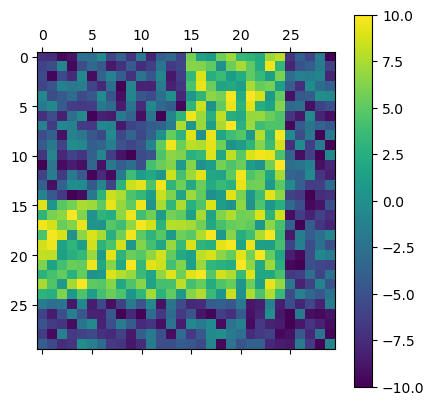

In [5]:
M = np.loadtxt('../../DataSets/DL-ToyImage.csv')
plt.matshow(M)
plt.colorbar()
plt.show()

### Convolution Layer 

First, we're going to try out convlution on this image. Here's a convolution filter matrix for us to test this onn.

[[1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1.]]


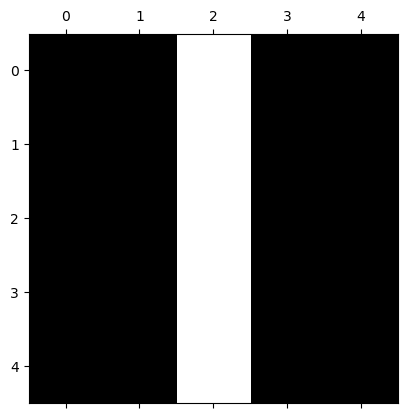

In [8]:
F = np.zeros((5,5))
F[:,:2] = 1
F[:, 3:] = 1
plt.spy(F)
print(F)
plt.show()

&#9989; **<font color=red>Do this:</font>** Extract a portion of the matrix $M$ from the top left of the same size as the filter matrix $F$ and take the dot product of the two. This is the entry that would go in entry $[0, 0]$ of the convolved image.

In [ ]:
# Your code here

In [ ]:
##ANSWER##
np.sum(np.dot(M[:F.shape[0], :F.shape[1]], F))

-501.59999999999997

&#9989; **<font color=red>Do this:</font>** Do the same thing, but shifted right by one. This is the entry that would go in entry $[0, 1]$ of the convolved image. 

In [ ]:
# Your code here

In [11]:
##ANSWER##
np.sum(np.dot(M[:F.shape[0], 1:1+F.shape[1]], F))

-502.4

&#9989; **<font color=red>Do this:</font>** Now, do this for every entry in the matrix. Update this `NewM` matrix so that each entry is the convolution of the input image. 

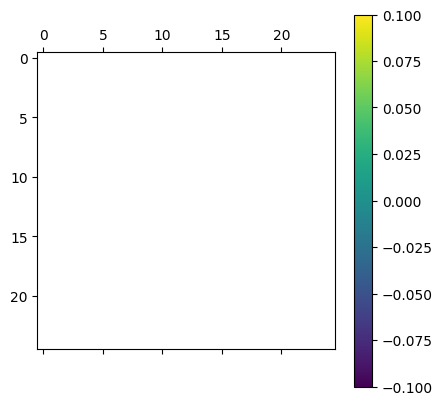

In [5]:
NewM = np.zeros((30-F.shape[0],30-F.shape[0]))
for i in range(NewM.shape[0]):
    for j in range(NewM.shape[1]):
        NewM[i,j] = np.NaN #<----------- you need to fix this
        
plt.matshow(NewM)
plt.colorbar()
plt.show()

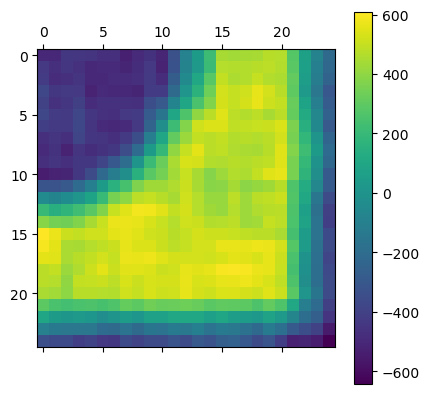

In [12]:
##ANSWER##

NewM = np.zeros((30-F.shape[0],30-F.shape[0]))
for i in range(NewM.shape[0]):
    for j in range(NewM.shape[1]):
        NewM[i,j] = np.sum(np.dot(M[i:i+F.shape[0], j:j+F.shape[1]], F))
plt.matshow(NewM)
plt.colorbar()
plt.show()

&#9989; **<font color=red>Do this:</font>** Here's a different filter. What happens when you convolve the image with this one instead? 

[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


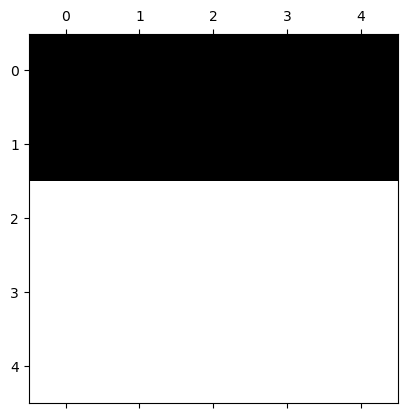

In [17]:
F = np.zeros((5,5))
F[:2,:] = 1
print(F)
plt.spy(F)
plt.show()

In [14]:
# Your code here

In [15]:
##ANSWER##

NewM = np.zeros((30-5,30-5))
for i in range(30-5):
    for j in range(30-5):
        NewM[i,j] = np.sum(np.dot(M[i:i+5, j:j+5], F))
plt.matshow(NewM)
plt.colorbar()

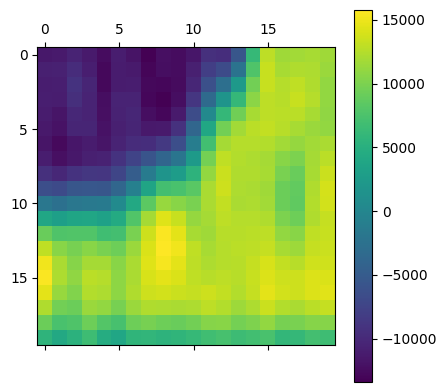

In [10]:
##ANSWER## 
# Trying a second time for fun
NewM2 = np.zeros((30-5*2,30-5*2))
for i in range(30-5*2):
    for j in range(30-5*2):
        NewM2[i,j] = np.sum(np.dot(NewM[i:i+5, j:j+5], F))
plt.matshow(NewM2)
plt.colorbar()

### Pooling Layer

After our convolution layer, we often build a pooling layer. 

&#9989; **<font color=red>Do this:</font>** Fix up the following code to create a pooled image from your convolved image.

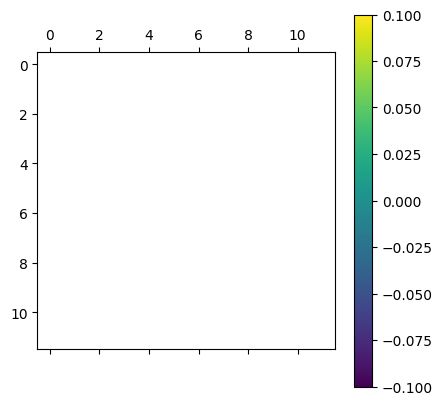

In [15]:
poolM = np.zeros( (NewM.shape[0]//2, NewM.shape[1]//2) )
for i in range(NewM.shape[0]//2):
    for j in range(NewM.shape[0]//2):
        poolM[i,j] = np.NaN #<------------Fix this

plt.matshow(poolM)
plt.colorbar()
plt.show()

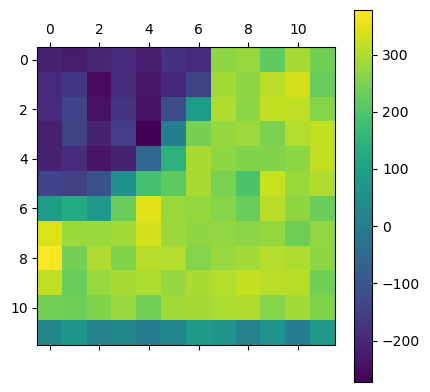

In [18]:
##ANSWER##
poolM = np.zeros( (NewM.shape[0]//2, NewM.shape[1]//2) )
for i in range(NewM.shape[0]//2):
    for j in range(NewM.shape[0]//2):
        poolM[i,j] = np.max(NewM[2*i:2*i+2,2*j:2*j+2])

plt.matshow(poolM)
plt.colorbar()
plt.show()

## Playing with a pre-trained classifier
As with the regular neural nets, trying to train our own CNN is beyond the scope of the class. But we can play with some toys to see how the trained versions work. 

Open the following in another browser tab to answer the questions below: https://poloclub.github.io/cnn-explainer/


&#9989; **<font color=red>Q:</font>** 
1. Read the section below on what each layer of the network does. 
1. What is the 2nd top prediction output for the bell pepper picture?
1. Clicking on the "+" button lets you upload a picture.  What does your face get classified as?



-----
### Congratulations, we're done!
Written by Dr. Liz Munch, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [2]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

from jupyterinstruct import InstructorNotebook
import os
this_notebook = os.path.basename(globals()['__vsc_ipynb_file__'])

studentnotebook = InstructorNotebook.makestudent(this_notebook)

InstructorNotebook.validate(studentnotebook)

Myfilename CMSE381-Lec31-CNN-INSTRUCTOR.ipynb


CMSE381-Lec31_CNN.ipynb


Validating Notebook ./CMSE381-Lec31_CNN.ipynb


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


   ERROR: File Doesn't Exist - ../../DataSets/DataSets.md#dl-toyimage


1